<a href="https://colab.research.google.com/github/mukteswarnayak17/B2B-SaaS-Churn-Risk-Customer-Health-Analysis/blob/main/MC2_AI_Discovers_the_Story.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Authenticate your Google account (this will trigger a permission popup)
from google.colab import auth
auth.authenticate_user()

# 2. Import the required libraries
import gspread
from google.auth import default
import pandas as pd

# 3. Authorize Google Sheets access
creds, _ = default()
gc = gspread.authorize(creds)

# 4. Open the Google Sheet using your exact URL
sheet_url = "https://docs.google.com/spreadsheets/d/1XsKq-KpIuJaseodMjL5YLVl71t_2G4Ka9l0DIFgpews/edit?gid=1061672764#gid=1061672764"
worksheet = gc.open_by_url(sheet_url).sheet1

# 5. Extract the data and load it into a pandas DataFrame called 'df'
rows = worksheet.get_all_values()
df = pd.DataFrame.from_records(rows[1:], columns=rows[0])

# 6. Display the first 5 rows to confirm it worked
display(df.head())

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
0,1001,6/1/2026,C001,Laptop,Electronics,Delhi,1,65000,8000
1,1002,6/3/2026,C002,Phone,Electronics,Delhi,2,50000,6000
2,1003,3/3/2026,C003,Headphones,Electronics,Mumbai,1,5000,1200
3,1004,6/5/2026,C004,Chair,Furniture,Bangalore,3,12000,2500
4,1005,7/3/2026,C314,Vacuum Cleaner,Home,Delhi,0,8506,1455


In [ ]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
0,1001,6/1/2026,C001,Laptop,Electronics,Delhi,1,65000,8000
1,1002,6/3/2026,C002,Phone,Electronics,Delhi,2,50000,6000
2,1003,3/3/2026,C003,Headphones,Electronics,Mumbai,1,5000,1200
3,1004,6/5/2026,C004,Chair,Furniture,Bangalore,3,12000,2500
4,1005,7/3/2026,C314,Vacuum Cleaner,Home,Delhi,0,8506,1455


In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}\n")

print("--- 3: Column Names ---")
print(df.columns.tolist())
print("\n")

print("--- 4: Data Types ---")
print(df.dtypes)
print("\n")

print("--- 5: Summary Statistics ---")
display(df.describe())
print("\n")

print("--- 6: Unique Categorical Values ---")
print("Categories:", df['Category'].unique())
print("Regions:", df['Region'].unique())
print("Products:", df['Product'].unique())
print("\n")

# 7. First 5 rows
print("--- 7: First 5 Rows ---")
display(df.head())

Number of rows: 2000
Number of columns: 9

--- 3: Column Names ---
['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category', 'Region', 'Quantity', 'Revenue', 'Profit']


--- 4: Data Types ---
Order_ID       object
Order_Date     object
Customer_ID    object
Product        object
Category       object
Region         object
Quantity       object
Revenue        object
Profit         object
dtype: object


--- 5: Summary Statistics ---


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
count,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,1977,234,416,25,5,8,7,1903,1811
top,1391,5/31/2026,C476,Perfume,Electronics,Chennai,1,47679.63913,13152.51211
freq,2,20,45,106,587,302,354,27,9




--- 6: Unique Categorical Values ---
Categories: ['Electronics' 'Furniture' 'Home' 'Beauty' 'Apparel']
Regions: ['Delhi' 'Mumbai' 'Bangalore' 'Chennai' 'Kolkata' 'Hyderabad'
 'Unknown Region' 'Pune']
Products: ['Laptop' 'Phone' 'Headphones' 'Chair' 'Vacuum Cleaner' 'Camera'
 'Bookshelf' 'Desk' 'Makeup Kit' 'Shoes' 'Jeans' 'Tablet' 'Speaker'
 'Microwave' 'Skincare Set' 'Table' 'Sofa' 'Cookware Set' 'T-Shirt'
 'Kurta' 'Jacket' 'Smartwatch' 'Blender' 'Perfume' '']


--- 7: First 5 Rows ---


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
0,1001,6/1/2026,C001,Laptop,Electronics,Delhi,1,65000,8000
1,1002,6/3/2026,C002,Phone,Electronics,Delhi,2,50000,6000
2,1003,3/3/2026,C003,Headphones,Electronics,Mumbai,1,5000,1200
3,1004,6/5/2026,C004,Chair,Furniture,Bangalore,3,12000,2500
4,1005,7/3/2026,C314,Vacuum Cleaner,Home,Delhi,0,8506,1455


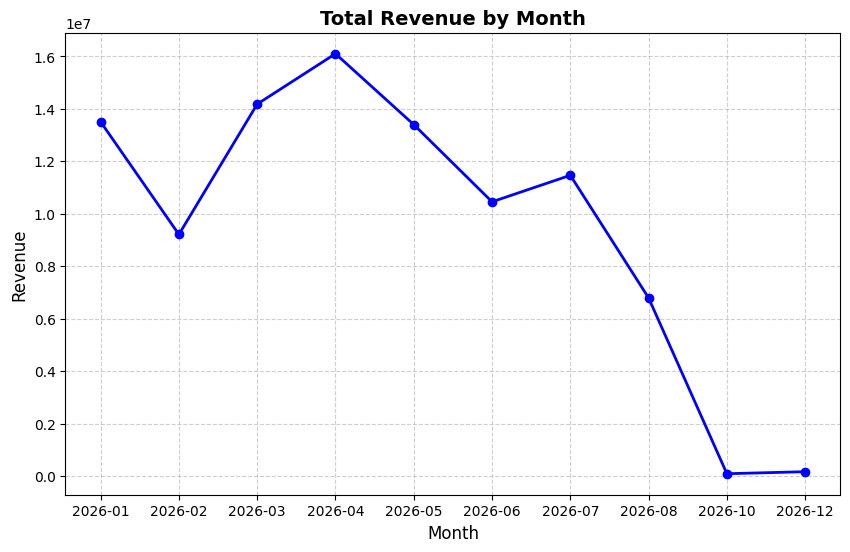

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Safety check: Ensure Revenue as a number so it can calculate totals
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

# Convert Order_Date into a proper date format
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract the month (Creates a 'Year-Month' format like 2026-06)
df['Month'] = df['Order_Date'].dt.to_period('M')

# Calculate total Revenue for each month and keep chronological order
# Grouping by our new 'Month' column automatically sorts the timeline correctly
monthly_revenue = df.groupby('Month')['Revenue'].sum()


plt.figure(figsize=(10, 6))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', linewidth=2, color='blue')

plt.title('Total Revenue by Month', fontsize=14, fontweight='bold')

plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the final chart
plt.show()

Observation:

Highest revenue month was April Month and the Revenue is ₹16,102,470


Lowest revenue month was October Month and the revenue is ₹86,165

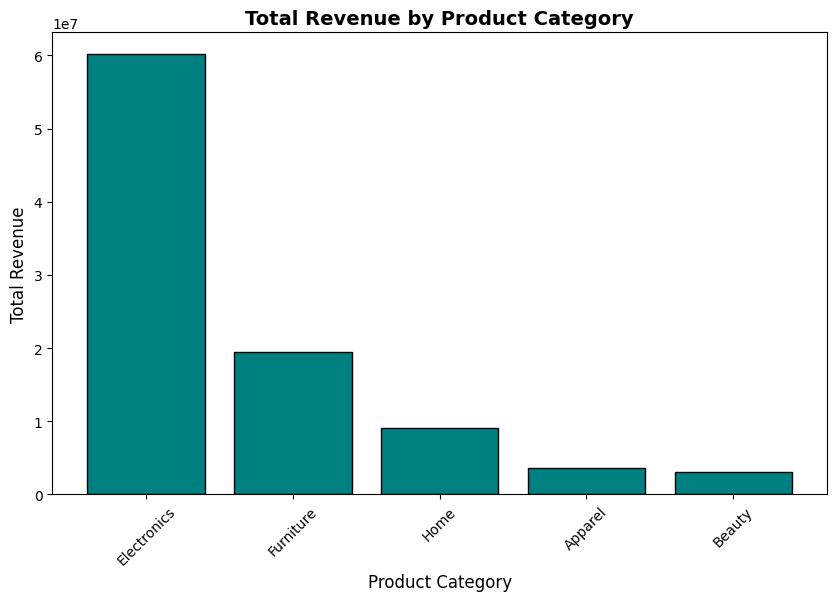

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Safety check: Ensure  Revenue as a number for calculations
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

# Group by Category and calculate total Revenue
category_revenue = df.groupby('Category')['Revenue'].sum()

# 3. Sort categories from highest to lowest revenue
category_revenue = category_revenue.sort_values(ascending=False)

# 4. Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(category_revenue.index, category_revenue.values, color='teal', edgecolor='black')


plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)

# Display the final chart
plt.show()

Observation:

Highest-revenue category is Electronics and the revenue is ₹60,151,309

Lowest-revenue category is Beauty and the revenue is ₹3,099,721


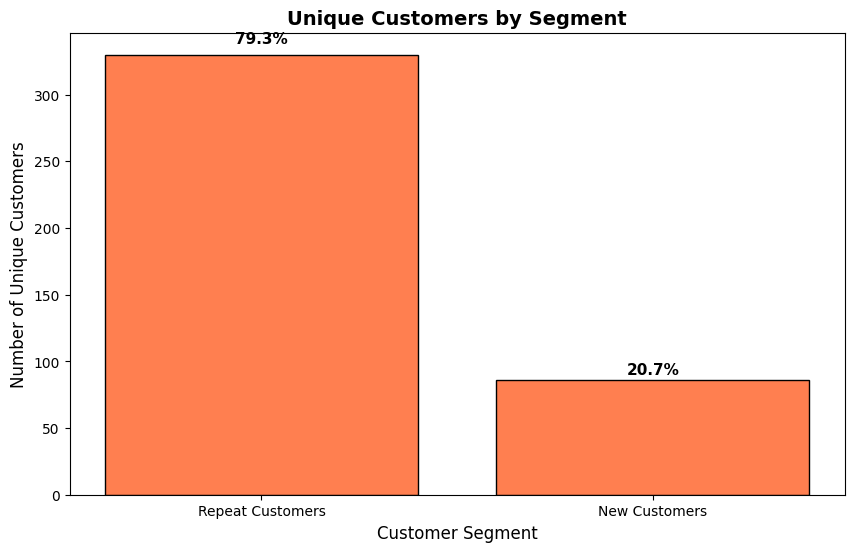

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create the missing 'Customer_Segment' column
# Count how many orders each customer made
order_counts = df['Customer_ID'].value_counts()

# Define a rule: >1 order = 'Repeat Customers', 1 order = 'New Customers'
def assign_segment(count):
    if count > 1:
        return 'Repeat Customers'
    else:
        return 'New Customers'

# Apply the rule and add the new column to df
df['Customer_Segment'] = df['Customer_ID'].map(order_counts).apply(assign_segment)

segment_counts = df.groupby('Customer_Segment')['Customer_ID'].nunique()

# Sort from largest segment to smallest for a cleaner chart
segment_counts = segment_counts.sort_values(ascending=False)

# Calculate the percentage of customers in each segment
total_unique_customers = segment_counts.sum()
segment_percentages = (segment_counts / total_unique_customers) * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_counts.index, segment_counts.values, color='coral', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / total_unique_customers) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{percentage:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')


plt.title('Unique Customers by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Unique Customers', fontsize=12)

# Display the chart
plt.show()

Observation:

The largest customer segment was Repeat Customers.

It represented approximately 79.33% of customers.

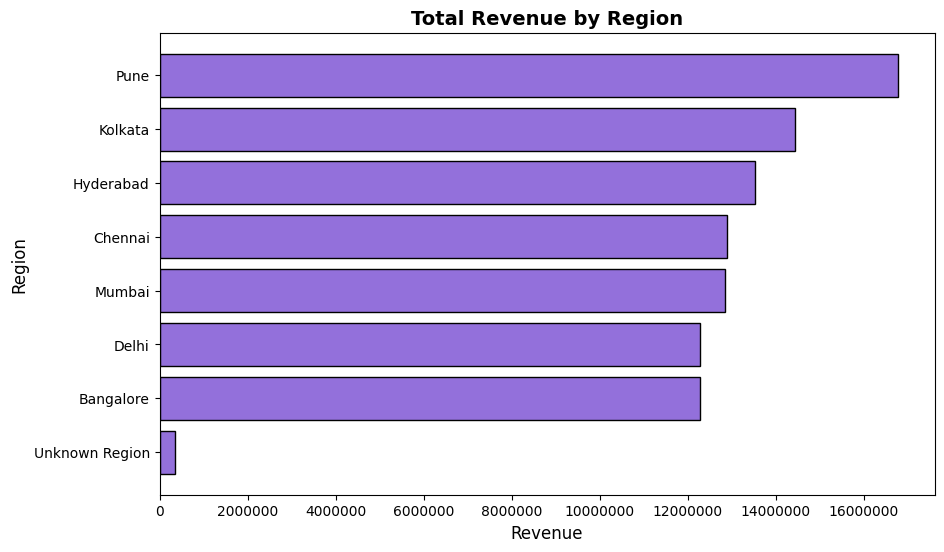

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Safety check: Ensure Revenue is treated as a number for calculations
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

# Group the data by Region and calculate total Revenue
region_revenue = df.groupby('Region')['Revenue'].sum()

# Sort regions from lowest to highest so the highest appears at the top of the horizontal chart
region_revenue = region_revenue.sort_values(ascending=True)


plt.figure(figsize=(10, 6))
plt.barh(region_revenue.index, region_revenue.values, color='mediumpurple', edgecolor='black')
plt.title('Total Revenue by Region', fontsize=14, fontweight='bold')
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Region', fontsize=12)

# Prevent scientific notation (e.g., 1e7) on the x-axis for easier reading
plt.ticklabel_format(style='plain', axis='x')

# Display the chart
plt.show()

Observation:

The highest-revenue region was Pune (₹16,770,134).

The lowest-revenue region was Bangalore (₹12,271,524).

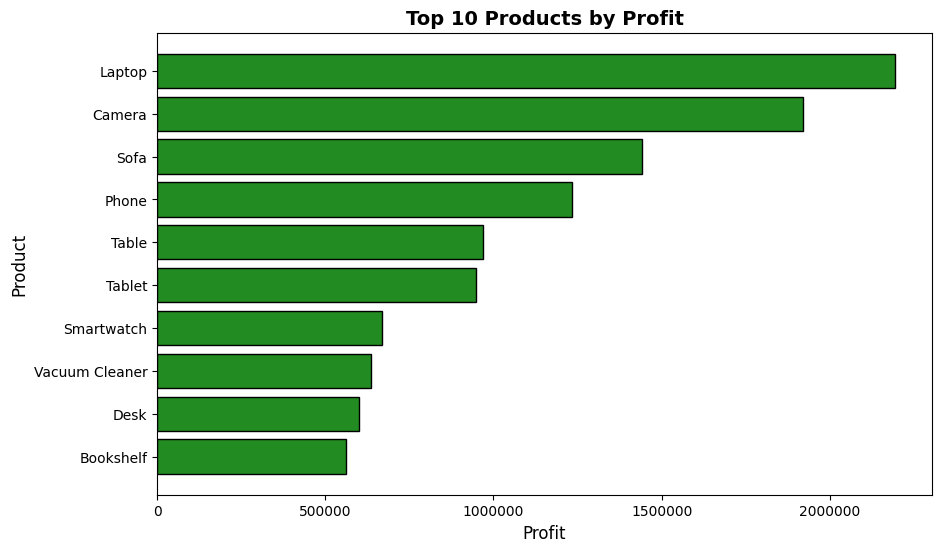

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Safety check: Ensure Profit is treated as a number for calculations
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

# Group the data by Product and calculate total Profit
product_profit = df.groupby('Product')['Profit'].sum()

# Sort products from highest to lowest and select the top 10
top_10_products = product_profit.sort_values(ascending=False).head(10)

# Re-sort ascending so the highest profit item appears at the very top of the horizontal chart
top_10_products = top_10_products.sort_values(ascending=True)


plt.figure(figsize=(10, 6))
plt.barh(top_10_products.index, top_10_products.values, color='forestgreen', edgecolor='black')
plt.title('Top 10 Products by Profit', fontsize=14, fontweight='bold')
plt.xlabel('Profit', fontsize=12)
plt.ylabel('Product', fontsize=12)

plt.ticklabel_format(style='plain', axis='x')

# Display the chart
plt.show()

Observation:

The highest-profit product was Laptop (₹2,194,106).

The second-highest-profit product was Camera (₹1,921,456).

Insight 1:

Cash Flow & Resource Planning
Revenue fluctuates drastically, peaking in April (₹16.1M) and dropping to a low of ₹86,165. This extreme variance indicates a highly seasonal sales cycle, meaning the business must heavily rely on early-year cash flow to sustain operations during severe late-year downturns.

Insight 2:

Growth vs. Cutbacks: While Electronics is the clear core revenue driver, Beauty's low contribution suggests it either requires a revamped targeted marketing strategy or a product line review to justify its ongoing operational costs.

Insight 3:

Retention Strength: Nearly 80% of the customer base consists of returning shoppers, indicating excellent product satisfaction and brand loyalty. The business should capitalize on this by implementing a VIP loyalty or referral program to drive even more value from these proven buyers.

Insight 4:

Replicating Success: Pune is the top-performing market, highlighting a strong local product-market fit. The business should identify the specific sales channels or promotional strategies working in Pune and test them in Bangalore to help close the ₹4.5M revenue gap.

Insight 5:

Inventory Prioritization: High-ticket electronics like Laptops and Cameras are the primary profit engines for the business. Supply chain efforts must ensure these specific items are never out of stock to protect the company's bottom line.

Hypothesis 1:

The April revenue peak might be driven by major seasonal marketing campaigns, holiday sales, or year-end buying cycles, whereas the severe drop in October could represent a post-seasonal spending lull where promotional efforts were paused.

Hypothesis 2:

Price Point Variance or Marketing Focus:
The dominance of the Electronics category could simply be due to the much higher average price points of tech items (like Laptops and Cameras) compared to Furniture or Beauty, or the business may be dedicating the vast majority of its advertising budget specifically to promote tech products.

Hypothesis 3:

The massive amount of profit generated by blank or unidentified product entries might be caused by a system integration error, where bundled items, promotional freebies, or manually entered offline sales possibly fail to sync their exact product names into the primary database, resulting in missing metadata.

Recommendation 1:

Introduce targeted mid-year retention campaigns, loyalty discounts, or flash sales ahead of historically slow periods like October to maintain steady cash flow and reduce severe revenue drops.

Recommendation 2:

Audit the marketing budget to ensure underperforming categories like Beauty receive adequate promotional support, rather than relying exclusively on high-ticket Electronics to drive growth.

Recommendation 3:

Implement stricter data validation checks at checkout and regular database audits to minimize blank product entries and ensure all sales are accurately tracked to their proper SKUs.